In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = r'/content/drive/MyDrive/Colab Notebooks/Indian_Kids_Screen_Time.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [ ]:
df.shape

(9712, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [ ]:
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')
df['Health_Impacts'].isnull().sum()

np.int64(0)

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Age: 11
Gender: 2
Avg_Daily_Screen_Time_hr: 899
Primary_Device: 4
Exceeded_Recommended_Limit: 2
Educational_to_Recreational_Ratio: 31
Health_Impacts: 16
Urban_or_Rural: 2


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9712.0,12.979201,3.162437,8.0,10.00,13.00,16.00,18.00
Avg_Daily_Screen_Time_hr,9712.0,4.352837,1.718232,0.0,3.41,4.44,5.38,13.89
Educational_to_Recreational_Ratio,9712.0,0.427226,0.073221,0.3,0.37,0.43,0.48,0.60


In [ ]:
print("Missing values in each column:\n", df.isnull().sum())
print("\nDuplicate rows in dataset:", df.duplicated().sum())

Missing values in each column:
 Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

Duplicate rows in dataset: 44


In [ ]:
df = df.drop_duplicates()
df.shape

(9668, 8)

In [ ]:
print("Gender:", df['Gender'].unique())
print("Primary_Device:", df['Primary_Device'].unique())
print("Urban_or_Rural:", df['Urban_or_Rural'].unique())

Gender: ['Male' 'Female']
Primary_Device: ['Smartphone' 'Laptop' 'TV' 'Tablet']
Urban_or_Rural: ['Urban' 'Rural']


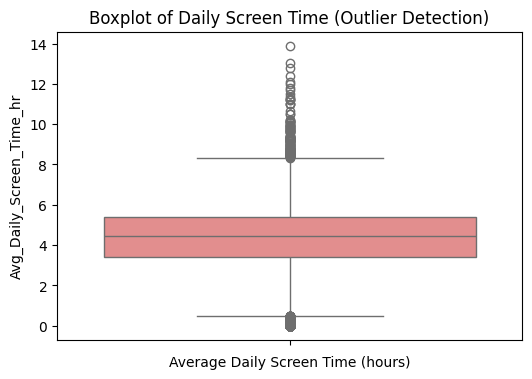

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(df['Avg_Daily_Screen_Time_hr'], color='lightcoral')
plt.title('Boxplot of Daily Screen Time (Outlier Detection)', fontsize=12)
plt.xlabel('Average Daily Screen Time (hours)')
plt.show()

In [ ]:
df = df[df['Avg_Daily_Screen_Time_hr'] > 0]
df.shape

(9474, 8)

/tmp/ipython-input-2323133346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age', data=df, palette='viridis')


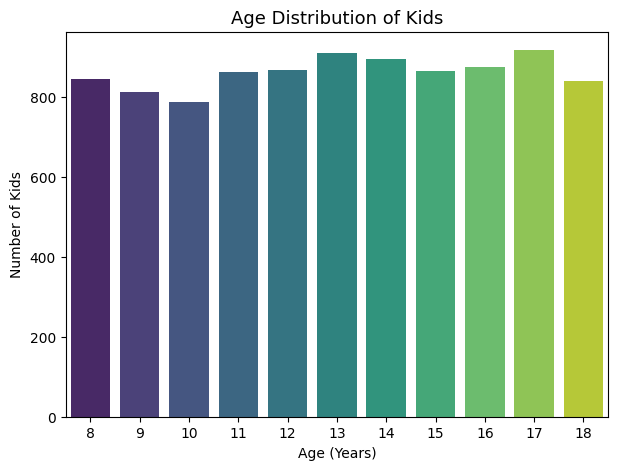

In [ ]:
# Univariate Analysis
plt.figure(figsize=(7,5))
sns.countplot(x='Age', data=df, palette='viridis')
plt.title('Age Distribution of Kids', fontsize=13)
plt.xlabel('Age (Years)')
plt.ylabel('Number of Kids')
plt.show()

/tmp/ipython-input-1221265023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


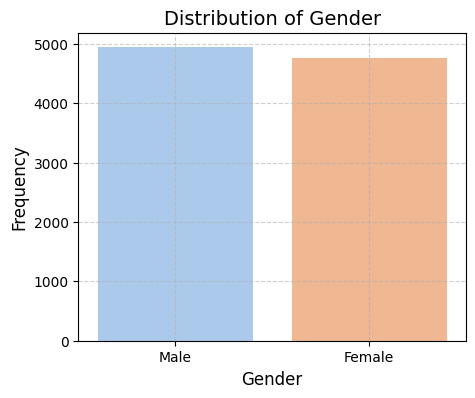

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Gender', palette='pastel')

plt.title('Distribution of Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

/tmp/ipython-input-3446152836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df, palette='magma')


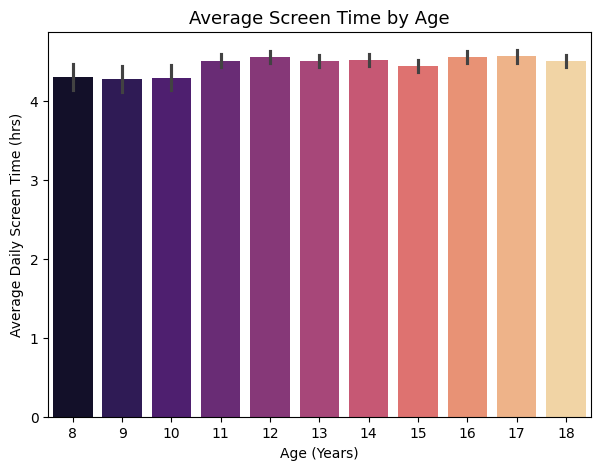

In [ ]:
# Bivariate Analysis
plt.figure(figsize=(7,5))
sns.barplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df, palette='magma')
plt.title('Average Screen Time by Age', fontsize=13)
plt.xlabel('Age (Years)')
plt.ylabel('Average Daily Screen Time (hrs)')
plt.show()

/tmp/ipython-input-2248780736.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='coolwarm')


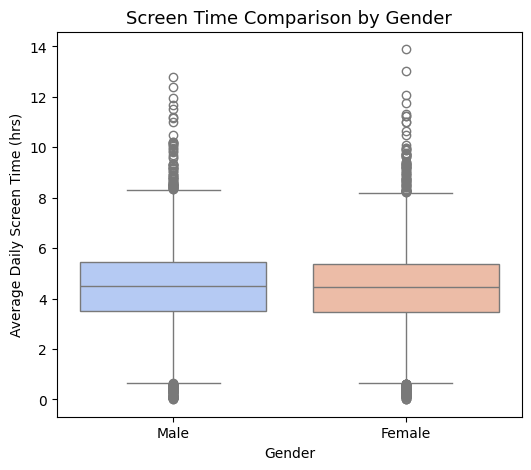

In [ ]:
# Bivariate Analysis
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='coolwarm')
plt.title('Screen Time Comparison by Gender', fontsize=13)
plt.xlabel('Gender')
plt.ylabel('Average Daily Screen Time (hrs)')
plt.show()

/tmp/ipython-input-2055764854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df, palette='plasma')


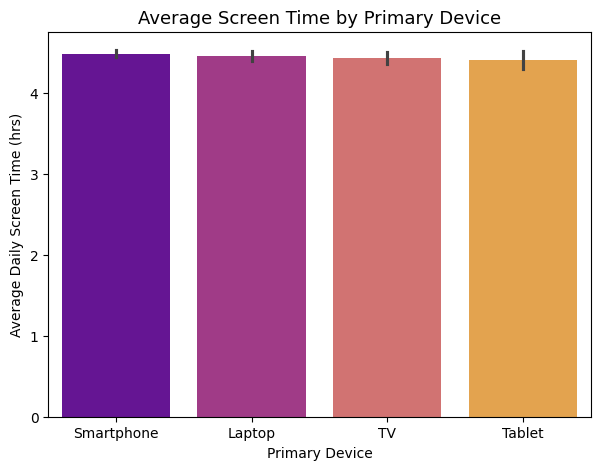

In [ ]:
# Bivariate Analysis
plt.figure(figsize=(7,5))
sns.barplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df, palette='plasma')
plt.title('Average Screen Time by Primary Device', fontsize=13)
plt.xlabel('Primary Device')
plt.ylabel('Average Daily Screen Time (hrs)')
plt.show()

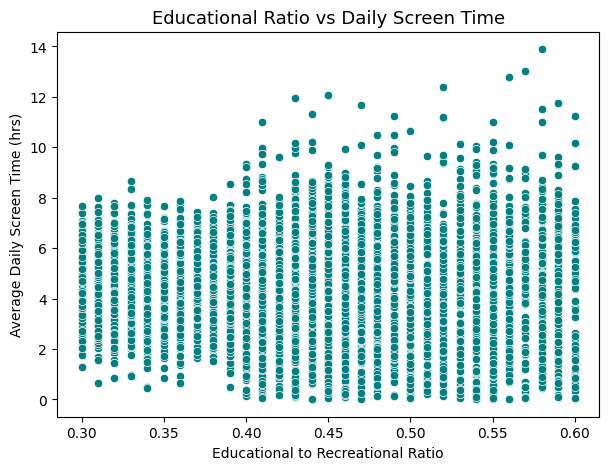

In [ ]:
# Bivariate Analysis
plt.figure(figsize=(7,5))
sns.scatterplot(x='Educational_to_Recreational_Ratio', y='Avg_Daily_Screen_Time_hr', data=df, color='teal')
plt.title('Educational Ratio vs Daily Screen Time', fontsize=13)
plt.xlabel('Educational to Recreational Ratio')
plt.ylabel('Average Daily Screen Time (hrs)')
plt.show()

/tmp/ipython-input-813620537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exceeded_Recommended_Limit', data=df, palette='autumn')


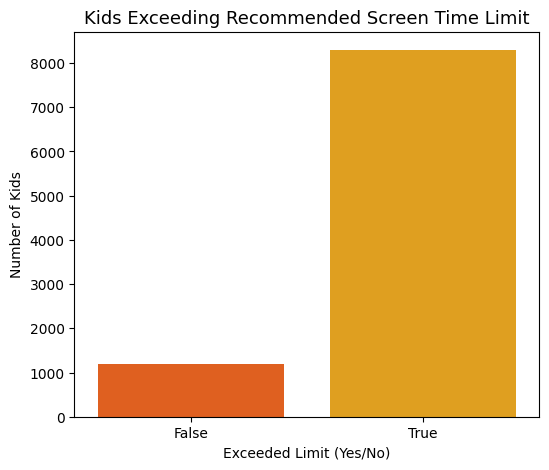

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(x='Exceeded_Recommended_Limit', data=df, palette='autumn')
plt.title('Kids Exceeding Recommended Screen Time Limit', fontsize=13)
plt.xlabel('Exceeded Limit (Yes/No)')
plt.ylabel('Number of Kids')
plt.show()

/tmp/ipython-input-4220849778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(health_issues.keys()), y=list(health_issues.values()), palette='crest')


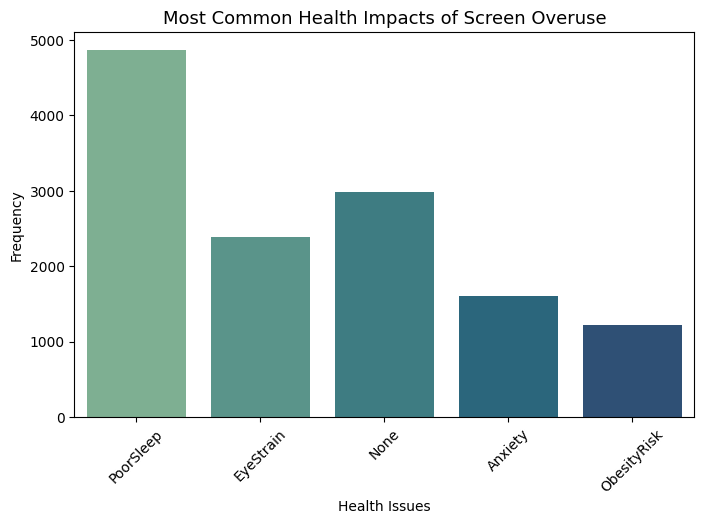

In [ ]:
from collections import Counter
health_issues = Counter(','.join(df['Health_Impacts']).replace(' ', '').split(','))
plt.figure(figsize=(8,5))
sns.barplot(x=list(health_issues.keys()), y=list(health_issues.values()), palette='crest')
plt.title('Most Common Health Impacts of Screen Overuse', fontsize=13)
plt.xlabel('Health Issues')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

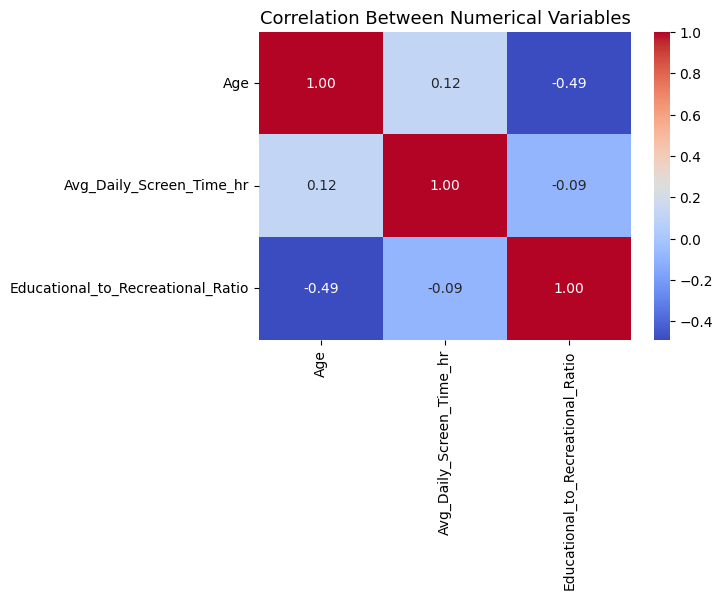

In [ ]:
# Multivariate Analysis
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Variables', fontsize=13)
plt.show()

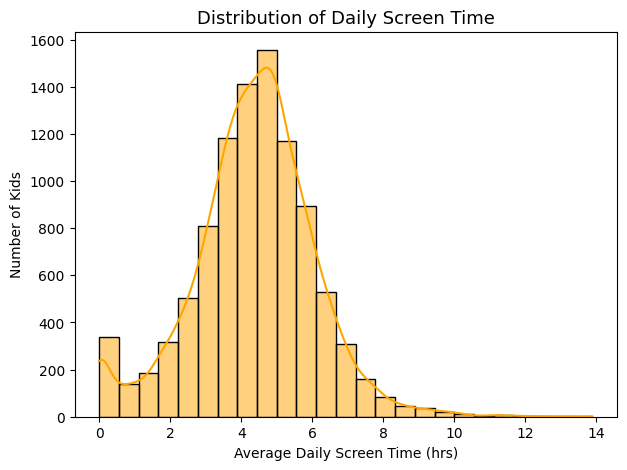

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], kde=True, color='orange', bins=25)
plt.title('Distribution of Daily Screen Time', fontsize=13)
plt.xlabel('Average Daily Screen Time (hrs)')
plt.ylabel('Number of Kids')
plt.show()

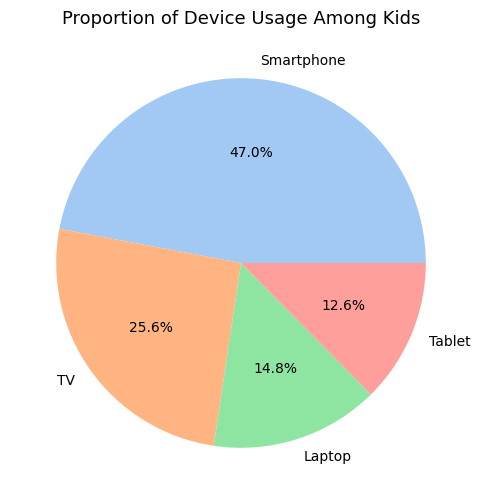

In [ ]:
plt.figure(figsize=(6,6))
df['Primary_Device'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proportion of Device Usage Among Kids', fontsize=13)
plt.ylabel('')
plt.show()

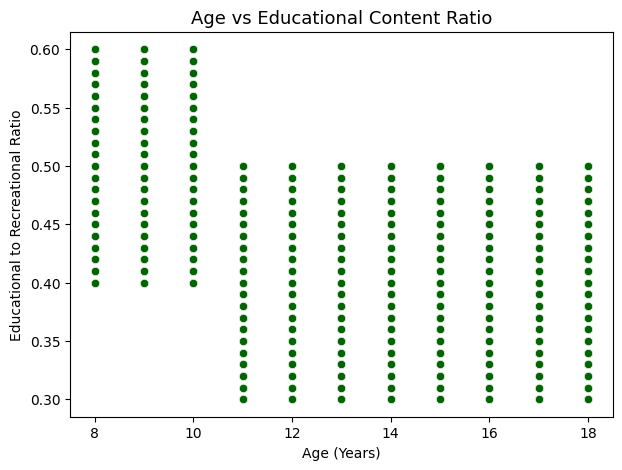

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Age', y='Educational_to_Recreational_Ratio', data=df, color='darkgreen')
plt.title('Age vs Educational Content Ratio', fontsize=13)
plt.xlabel('Age (Years)')
plt.ylabel('Educational to Recreational Ratio')
plt.show()

In [14]:
def screen_time_recommendation(age, gender, location, screen_time, ratio):
    print("\nScreen Time Recommendation\n")

    if screen_time > 5:
        print("Your screen time is above the healthy limit. Consider reducing it.")
    elif screen_time < 1.5:
        print("Your screen time is low. Good balance.")
    else:
        print("Your screen time is moderate.")

    if ratio < 0.4:
        print("Your educational screen usage is low. Aim for 0.45 or above.")
    else:
        print("Your educational usage seems fine.")

    if gender.lower() == "male" and 13 <= age <= 16 and screen_time > 6:
        print("Teenage boys often spend more time on gaming. Try to balance it.")

    if gender.lower() == "female" and age < 12 and screen_time > 5:
        print("Consider limiting screen use in late evenings.")

    if location.lower() == "urban" and screen_time > 6:
        print("High urban usage can lead to poor sleep. Avoid screens before sleep.")
    elif location.lower() == "rural" and ratio < 0.35:
        print("Try to include more learning-based content in your usage.")

    if screen_time > 8:
        print("Very high screen time. Risk of anxiety, poor sleep or low focus.")

    print("\nMaintain digital balance for better health and learning.\n")

In [15]:
def predict_health_risks(age, gender, location, screen_time, ratio):
    print("\nPossible Health Impact Prediction\n")

    risks = []

    if screen_time > 6:
        risks.append("Poor Sleep")

    if ratio < 0.35:
        risks.append("Low Focus")

    if screen_time > 8:
        risks.append("Anxiety")

    if gender.lower() == 'male' and screen_time > 7:
        risks.append("Eye Strain")

    if location.lower() == 'urban' and screen_time > 6:
        risks.append("Headache, Sleep Disruption")

    if len(risks) == 0:
        print("No high-risk pattern detected based on your inputs.")
    else:
        print("You may be at risk of:")
        for r in risks:
            print("•", r)

    print("\nPlease take screen breaks, avoid using phones at night, and increase learning content ratio.\n")

In [16]:
def improvement_suggestions(screen_time, ratio):
    print("\nImprovement Suggestions\n")

    if screen_time > 5:
        print("- Try reducing your screen time by 30–60 mins per day.")
    else:
        print("- Good job keeping your screen time in control.")

    if ratio < 0.4:
        print("- Use educational apps like BYJU'S, Khan Academy, Duolingo.")

    if ratio >= 0.5:
        print("- Maintain your habit of using screens for learning.")

    print("- Avoid screens 1 hour before bedtime.")

In [17]:
# Getting inputs
age = int(input("Age: "))
gender = input("Gender (Male/Female): ")
location = input("Location (Urban/Rural): ")
screen_time = float(input("Average Daily Screen Time (in hrs): "))
ratio = float(input("Educational to Recreational Usage Ratio (0 to 1): "))

# Call all functions made till now
screen_time_recommendation(age, gender, location, screen_time, ratio)
predict_health_risks(age, gender, location, screen_time, ratio)
improvement_suggestions(screen_time, ratio)

Age: 16
Gender (Male/Female): Male
Location (Urban/Rural): Urban
Average Daily Screen Time (in hrs): 5
Educational to Recreational Usage Ratio (0 to 1): 0.3

Screen Time Recommendation

Your screen time is moderate.
Your educational screen usage is low. Aim for 0.45 or above.

Maintain digital balance for better health and learning.


Possible Health Impact Prediction

You may be at risk of:
• Low Focus

Please take screen breaks, avoid using phones at night, and increase learning content ratio.


Improvement Suggestions

- Good job keeping your screen time in control.
- Use educational apps like BYJU'S, Khan Academy, Duolingo.
- Avoid screens 1 hour before bedtime.


In [8]:
# Create a focused dataset for recommendations
important_features = [
    'Age',
    'Gender',
    'Avg_Daily_Screen_Time_hr',
    'Primary_Device',
    'Exceeded_Recommended_Limit',
    'Educational_to_Recreational_Ratio',
    'Health_Impacts',
    'Urban_or_Rural'
]

df_reco = df[important_features]
df_reco.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [5]:
# Define rule-based recommendation function
def generate_recommendation(row):
    recommendations = []

    # 1. Screen time based advice
    if row['Avg_Daily_Screen_Time_hr'] > 6:
        recommendations.append("⚠️ Reduce screen time; consider a digital detox.")
    elif 4 <= row['Avg_Daily_Screen_Time_hr'] <= 6:
        recommendations.append("🕒 Maintain balanced usage (below 6 hours ideal).")
    else:
        recommendations.append("✅ Great! Your screen time is within healthy limits.")

    # 2. Educational ratio
    if row['Educational_to_Recreational_Ratio'] < 0.4:
        recommendations.append("📚 Increase study-related screen usage (learning apps, courses).")
    else:
        recommendations.append("🎯 Good educational balance maintained.")

    # 3. Health impacts
    if isinstance(row['Health_Impacts'], str):  # handle NaN safely
        if 'Poor Sleep' in row['Health_Impacts']:
            recommendations.append("🌙 Avoid screen use before bed; enable night mode.")
        if 'Eye Strain' in row['Health_Impacts']:
            recommendations.append("👁️ Take frequent eye breaks and adjust brightness.")
        if 'Anxiety' in row['Health_Impacts']:
            recommendations.append("🧘 Try relaxation breaks or mindfulness activities.")

    # 4. Device-based suggestion
    if row['Primary_Device'] == 'Smartphone':
        recommendations.append("📱 Use focus or parental control apps.")
    elif row['Primary_Device'] == 'Laptop':
        recommendations.append("💻 Schedule short breaks during study sessions.")
    elif row['Primary_Device'] == 'TV':
        recommendations.append("📺 Limit binge-watching; take screen-free intervals.")

    return recommendations

In [9]:
df_reco['Recommendations'] = df_reco.apply(generate_recommendation, axis=1)
df_reco[['Age', 'Avg_Daily_Screen_Time_hr', 'Primary_Device', 'Health_Impacts', 'Recommendations']].head(10)

,Age,Avg_Daily_Screen_Time_hr,Primary_Device,Health_Impacts,Recommendations
0,14,3.99,Smartphone,"Poor Sleep, Eye Strain",[✅ Great! Your screen time is within healthy l...
1,11,4.61,Laptop,Poor Sleep,[🕒 Maintain balanced usage (below 6 hours idea...
2,18,3.73,TV,Poor Sleep,[✅ Great! Your screen time is within healthy l...
3,15,1.21,Laptop,NaN,[✅ Great! Your screen time is within healthy l...
4,12,5.89,Smartphone,"Poor Sleep, Anxiety",[🕒 Maintain balanced usage (below 6 hours idea...
5,14,4.88,Smartphone,Poor Sleep,[🕒 Maintain balanced usage (below 6 hours idea...
6,17,2.97,TV,NaN,[✅ Great! Your screen time is within healthy l...
7,10,2.74,TV,NaN,[✅ Great! Your screen time is within healthy l...
8,14,4.61,Laptop,"Poor Sleep, Anxiety",[🕒 Maintain balanced usage (below 6 hours idea...
9,18,3.24,Tablet,"Poor Sleep, Obesity Risk",[✅ Great! Your screen time is within healthy l...


In [10]:
df_reco['Recommendations_Text'] = df_reco['Recommendations'].apply(lambda x: '; '.join(x))
df_reco[['Age', 'Avg_Daily_Screen_Time_hr', 'Primary_Device', 'Health_Impacts', 'Recommendations_Text']].head(10)

,Age,Avg_Daily_Screen_Time_hr,Primary_Device,Health_Impacts,Recommendations_Text
0,14,3.99,Smartphone,"Poor Sleep, Eye Strain",✅ Great! Your screen time is within healthy li...
1,11,4.61,Laptop,Poor Sleep,🕒 Maintain balanced usage (below 6 hours ideal...
2,18,3.73,TV,Poor Sleep,✅ Great! Your screen time is within healthy li...
3,15,1.21,Laptop,NaN,✅ Great! Your screen time is within healthy li...
4,12,5.89,Smartphone,"Poor Sleep, Anxiety",🕒 Maintain balanced usage (below 6 hours ideal...
5,14,4.88,Smartphone,Poor Sleep,🕒 Maintain balanced usage (below 6 hours ideal...
6,17,2.97,TV,NaN,✅ Great! Your screen time is within healthy li...
7,10,2.74,TV,NaN,✅ Great! Your screen time is within healthy li...
8,14,4.61,Laptop,"Poor Sleep, Anxiety",🕒 Maintain balanced usage (below 6 hours ideal...
9,18,3.24,Tablet,"Poor Sleep, Obesity Risk",✅ Great! Your screen time is within healthy li...


In [19]:
def simple_reco(age:int, screen_time:float, edu_ratio:float, device:str):
    device = device.capitalize()
    recs = []

    # screen time rule
    if screen_time > 6:
        recs.append("⚠️ High usage — consider a digital detox and limit total daily use.")
    elif screen_time > 3:
        recs.append("🕒 Moderate usage — try to keep daily screen time under 4–6 hours.")
    else:
        recs.append("✅ Healthy usage — keep the current routine and maintain breaks.")

    # educational balance rule
    if edu_ratio < 0.4:
        recs.append("📚 Low educational share — add learning apps or scheduled study sessions.")
    else:
        recs.append("🎯 Good educational balance — encourage more learning content.")

    # device-specific hint
    if device == "Smartphone":
        recs.append("📱 Use app timers / focus modes on the phone (lock social apps during study).")
    elif device == "Laptop":
        recs.append("💻 Use the Pomodoro technique: 25min work / 5min break.")
    elif device == "Tv":
        recs.append("📺 Prefer co-viewing with family and limit binge sessions.")
    elif device == "Tablet":
        recs.append("� tablet tip: use guided learning apps and parental controls.")

    # simple risk flag
    if screen_time > 8:
        risk = "Severe"
    elif screen_time > 6:
        risk = "High"
    elif screen_time > 4:
        risk = "Moderate"
    else:
        risk = "Low"

    return {"recommendations": recs, "risk_level": risk}

In [20]:
print(simple_reco(age=14, screen_time=6.5, edu_ratio=0.3, device='smartphone'))

{'recommendations': ['⚠️ High usage — consider a digital detox and limit total daily use.', '📚 Low educational share — add learning apps or scheduled study sessions.', '📱 Use app timers / focus modes on the phone (lock social apps during study).'], 'risk_level': 'High'}


In [22]:
def simple_reco():
    print("\n================= Screen Time Recommendation System =================\n")

    # Taking inputs from the user
    age = int(input("Enter your age (8–18): "))
    screen_time = float(input("Enter your total daily screen time (in hours): "))
    edu_ratio = float(input("Enter your educational-to-recreational ratio (0 to 1): "))
    device = input("Enter your primary device (Smartphone/Laptop/TV/Tablet): ").capitalize()

    recommendations = []  # list to store all advice

    # --- Screen Time Rule ---
    if screen_time > 6:
        recommendations.append("⚠️ High usage — try to reduce screen time below 6 hours.")
    elif screen_time > 3:
        recommendations.append("🕒 Moderate usage — you’re close to the healthy limit.")
    else:
        recommendations.append("✅ Excellent! Your screen time is healthy.")

    # --- Educational Ratio Rule ---
    if edu_ratio < 0.4:
        recommendations.append("📚 Focus more on educational content — try learning apps or courses.")
    else:
        recommendations.append("🎯 Great! You maintain a good study–fun balance.")

    # --- Device-Specific Suggestion ---
    if device == "Smartphone":
        recommendations.append("📱 Use focus mode or screen timers to reduce distractions.")
    elif device == "Laptop":
        recommendations.append("💻 Take 5-minute eye breaks every 30 minutes.")
    elif device == "Tv":
        recommendations.append("📺 Avoid binge-watching; keep sessions under 1 hour.")
    elif device == "Tablet":
        recommendations.append("📒 Use your tablet for guided learning and limit gaming hours.")

    # --- Risk Level ---
    if screen_time > 8:
        risk = "🔴 Severe Risk"
    elif screen_time > 6:
        risk = "🟠 High Risk"
    elif screen_time > 4:
        risk = "🟡 Moderate Risk"
    else:
        risk = "🟢 Low Risk"

    # --- Display Final Output ---
    print("\n================= Personalized Recommendations =================\n")
    print(f"Age: {age} years | Device: {device} | Total Screen Time: {screen_time} hrs | Edu-Ratio: {edu_ratio}")
    print(f"Risk Level: {risk}\n")
    for rec in recommendations:
        print("- " + rec)

    print("\n==================================================================\n")


# Run the function
simple_reco()


================= Screen Time Recommendation System =================

Enter your age (8–18): 15
Enter your total daily screen time (in hours): 5
Enter your educational-to-recreational ratio (0 to 1): 0.5
Enter your primary device (Smartphone/Laptop/TV/Tablet): Smartphone

================= Personalized Recommendations =================

Age: 15 years | Device: Smartphone | Total Screen Time: 5.0 hrs | Edu-Ratio: 0.5
Risk Level: 🟡 Moderate Risk

- 🕒 Moderate usage — you’re close to the healthy limit.
- 🎯 Great! You maintain a good study–fun balance.
- 📱 Use focus mode or screen timers to reduce distractions.




In [11]:
# Build supporting summary tables and a user-facing recommendation function
import numpy as np
from collections import Counter

# 1) estimate educational & recreational hours per record (from ratio + total)
#    edu_to_rec_ratio = edu/rec -> total = edu + rec = rec*(1+ratio) => rec = total/(1+ratio)
df_reco = df_reco.copy()
df_reco['Estimated_Recreational_hr'] = df_reco.apply(
    lambda r: r['Avg_Daily_Screen_Time_hr'] / (1 + r['Educational_to_Recreational_Ratio'])
    if r['Educational_to_Recreational_Ratio'] >= 0 else np.nan, axis=1)
df_reco['Estimated_Educational_hr'] = df_reco['Avg_Daily_Screen_Time_hr'] - df_reco['Estimated_Recreational_hr']

# 2) define an age-based recommended threshold (adaptive rule; change as you like)
def age_threshold(age):
    if age <= 10:
        return 2.0
    elif age <= 14:
        return 4.0
    else:
        return 6.0

# add age-based threshold column
df_reco['Threshold_Limit_hr'] = df_reco['Age'].apply(age_threshold)

# 3) build recom_df2 grouped by Age, Gender, Primary_Device with needed aggregates
recom_df2 = df_reco.groupby(['Age', 'Gender', 'Primary_Device']).agg(
    Threshold_Limit_hr = ('Threshold_Limit_hr', 'mean'),
    Avg_screen_time_per_criterias = ('Avg_Daily_Screen_Time_hr', 'mean'),
    Avg_Daily_Screen_Time_per_age_only = ('Avg_Daily_Screen_Time_hr', lambda x: df_reco.loc[x.index, 'Avg_Daily_Screen_Time_hr'].mean()),
    Avg_Educational_Screen_time = ('Estimated_Educational_hr', 'mean'),
    Avg_Recreational_Screen_time = ('Estimated_Recreational_hr', 'mean'),
    Educational_to_Recreational_Ratio = ('Educational_to_Recreational_Ratio', 'mean'),
).reset_index()

# 4) prepare health-impacts counts by Age and Primary_Device (explode multi-labels)
#    normalize Health_Impacts strings and split
health_df = df_reco[['Age','Primary_Device','Health_Impacts']].copy()
health_df['Health_Impacts'] = health_df['Health_Impacts'].fillna('None').astype(str)
health_df['Health_Impacts'] = health_df['Health_Impacts'].str.replace(' ', '')  # remove spaces
health_exploded = health_df.assign(Health_Impact = health_df['Health_Impacts'].str.split(',')).explode('Health_Impact')
Health_Impacts_count_df = (health_exploded
                           .groupby(['Age','Primary_Device','Health_Impact'])
                           .size()
                           .reset_index(name='Health_Impact_Count'))

# 5) a helper to get top health impacts for a group (Age, Gender, Device)
def top_health_impacts_for_group(age, gender, device, topn=3):
    # filter same-age & device users (to mirror intern logic using similar users)
    grp = df_reco[(df_reco['Age']==age) & (df_reco['Primary_Device']==device)]
    if grp.empty:
        return []
    cnt = Counter(','.join(grp['Health_Impacts'].fillna('None')).replace(' ','').split(','))
    # remove empty strings
    if '' in cnt: del cnt['']
    top = [k for k,v in cnt.most_common(topn)]
    return top

# 6) user-facing recommendation function (similar flow as the intern code)
def recommend_user(age:int, gender:str, device:str, edu_time:float, rec_time:float):
    # sanitize inputs
    gender = gender.capitalize()
    device = device.capitalize()
    screen_time = float(edu_time + rec_time)
    # find matching group row in recom_df2
    match = recom_df2[
        (recom_df2['Age']==age) &
        (recom_df2['Gender']==gender) &
        (recom_df2['Primary_Device']==device)
    ]
    if match.empty:
        # fallback: use age-only averages
        age_grp = recom_df2[recom_df2['Age']==age]
        if not age_grp.empty:
            row = age_grp.iloc[0]
        else:
            return {"error":"No matching group found. Try different Age/Gender/Device or ensure data contains similar profiles."}
    else:
        row = match.iloc[0]

    limit = float(row['Threshold_Limit_hr'])
    avg_detailed = float(row['Avg_screen_time_per_criterias'])
    avg_age_only = float(row['Avg_Daily_Screen_Time_per_age_only'])
    avg_edu_age = float(row['Avg_Educational_Screen_time'])
    avg_rec_age = float(row['Avg_Recreational_Screen_time'])
    avg_ratio_age = float(row['Educational_to_Recreational_Ratio'])

    # compose textual report lines
    report_lines = []
    report_lines.append(f"Entered Age: {age}, Gender: {gender}, Device: {device}")
    report_lines.append(f"Educational hrs: {edu_time:.2f}, Recreational hrs: {rec_time:.2f}, Total: {screen_time:.2f} hrs")

    # threshold / exceed message
    if screen_time > limit:
        report_lines.append(f"⚠️ You exceed the recommended limit of {limit:.2f} hrs by {screen_time - limit:.2f} hrs.")
    else:
        report_lines.append(f"✅ Within recommended limit ({limit:.2f} hrs) for your group.")

    # compare to group detailed and age-only
    diff_hr = screen_time - avg_detailed
    diff_pct = (diff_hr / avg_detailed) * 100 if avg_detailed != 0 else 0
    if diff_hr > 0:
        report_lines.append(f"Your usage is {diff_hr:.2f} hrs ({diff_pct:.1f}%) above avg for similar peers.")
    elif diff_hr < 0:
        report_lines.append(f"Your usage is {abs(diff_hr):.2f} hrs ({abs(diff_pct):.1f}%) below avg for similar peers.")
    else:
        report_lines.append("Your usage matches the avg for similar peers.")

    diff_age_hr = screen_time - avg_age_only
    diff_age_pct = (diff_age_hr / avg_age_only) * 100 if avg_age_only != 0 else 0
    if diff_age_hr > 0:
        report_lines.append(f"Compared to avg for age {age}, you are {diff_age_hr:.2f} hrs ({diff_age_pct:.1f}%) higher.")
    elif diff_age_hr < 0:
        report_lines.append(f"Compared to avg for age {age}, you are {abs(diff_age_hr):.2f} hrs ({abs(diff_age_pct):.1f}%) lower.")
    else:
        report_lines.append("You match the age group average exactly.")

    # edu / rec comparisons
    edu_diff_hr = edu_time - avg_edu_age
    edu_diff_pct = (edu_diff_hr / avg_edu_age) * 100 if avg_edu_age != 0 else 0
    if edu_diff_hr > 0:
        report_lines.append(f"Educational time is {edu_diff_hr:.2f} hrs ({edu_diff_pct:.1f}%) higher than peers.")
    elif edu_diff_hr < 0:
        report_lines.append(f"Educational time is {abs(edu_diff_hr):.2f} hrs ({abs(edu_diff_pct):.1f}%) lower than peers.")

    rec_diff_hr = rec_time - avg_rec_age
    rec_diff_pct = (rec_diff_hr / avg_rec_age) * 100 if avg_rec_age != 0 else 0
    if rec_diff_hr > 0:
        report_lines.append(f"Recreational time is {rec_diff_hr:.2f} hrs ({rec_diff_pct:.1f}%) higher than peers.")
    elif rec_diff_hr < 0:
        report_lines.append(f"Recreational time is {abs(rec_diff_hr):.2f} hrs ({abs(rec_diff_pct):.1f}%) lower than peers.")

    # edu/rec ratio
    if rec_time != 0:
        user_ratio = edu_time / rec_time
        report_lines.append(f"Your Educational:Recreational ratio = {user_ratio:.3f} (group avg = {avg_ratio_age:.3f})")
        diff_ratio = user_ratio - avg_ratio_age
        if diff_ratio > 0:
            report_lines.append("You focus more on educational content than peers.")
        elif diff_ratio < 0:
            report_lines.append("You focus more on recreational content than peers.")
    else:
        report_lines.append("No recreational time reported (ratio = ∞).")

    # health impacts among similar users (top 3)
    top_impacts = top_health_impacts_for_group(age, gender, device, topn=3)
    if top_impacts:
        report_lines.append("Most common health impacts among similar users: " + ", ".join(top_impacts))
        if screen_time > limit:
            report_lines.append("Exceeding time in this group is often linked to: " + ", ".join(top_impacts))
    else:
        report_lines.append("No sufficient health-impact data for this group.")

    # risk flag by exceed percentage
    exceed_pct = ((screen_time - limit) / limit) * 100
    if exceed_pct <= 0:
        risk = "Healthy"
    elif exceed_pct <= 20:
        risk = "Mild Risk"
    elif exceed_pct <= 50:
        risk = "High Risk"
    else:
        risk = "Severe Risk"
    report_lines.append(f"Risk Level: {risk}")

    # device recommendation by age (choose device with fewest summed health impact counts for that age)
    devices_for_age = Health_Impacts_count_df[Health_Impacts_count_df['Age']==age]
    if not devices_for_age.empty:
        # aggregate by device
        dev_sum = (devices_for_age.groupby('Primary_Device')['Health_Impact_Count']
                   .sum().reset_index(name='Health_Impacts_count'))
        best_row = dev_sum.loc[dev_sum['Health_Impacts_count'].idxmin()]
        best_device = best_row['Primary_Device']
        best_count = int(best_row['Health_Impacts_count'])
        report_lines.append(f"Device with fewest reported health issues for age {age}: {best_device} ({best_count} cases).")
        if device != best_device:
            report_lines.append(f"Consider switching from {device} to {best_device} for potentially healthier usage.")
    else:
        report_lines.append("No sufficient device-health data to recommend a device for your age.")

    return {"report": report_lines, "limit": limit, "risk": risk}

In [12]:
print("\n================= Screen Time Recommendation System =================\n")

try:
    age = int(input("Enter your age (8-18): "))
    gender = input("Enter your gender (Male/Female): ").capitalize()
    device = input("Enter your primary device (Smartphone/Laptop/TV/Tablet): ").capitalize()
    edu_time = float(input("Enter your daily educational screen time (in hours): "))
    rec_time = float(input("Enter your daily recreational screen time (in hours): "))

    result = recommend_user(age, gender, device, edu_time, rec_time)

    print("\n================= Personalized Report =================\n")

    if "error" in result:
        print(result["error"])
    else:
        for line in result["report"]:
            print(line)

    print("\n======================================================================\n")

except Exception as e:
    print(f"⚠️ Error: {e}")


================= Screen Time Recommendation System =================

Enter your age (8-18): 16
Enter your gender (Male/Female): Male
Enter your primary device (Smartphone/Laptop/TV/Tablet): Smartphone
Enter your daily educational screen time (in hours): 5
Enter your daily recreational screen time (in hours): 2

================= Personalized Report =================

Entered Age: 16, Gender: Male, Device: Smartphone
Educational hrs: 5.00, Recreational hrs: 2.00, Total: 7.00 hrs
⚠️ You exceed the recommended limit of 6.00 hrs by 1.00 hrs.
Your usage is 2.50 hrs (55.7%) above avg for similar peers.
Compared to avg for age 16, you are 2.50 hrs (55.7%) higher.
Educational time is 3.73 hrs (293.9%) higher than peers.
Recreational time is 1.23 hrs (38.0%) lower than peers.
Your Educational:Recreational ratio = 2.500 (group avg = 0.396)
You focus more on educational content than peers.
Most common health impacts among similar users: PoorSleep, EyeStrain, None
Exceeding time in this group i